## Notebook 4

This notebook illustrates the training and prediction of a very simple Neural Ordinary Differential Equation (NODEs) model.  The data is fictitiously generated from solving

$\frac{du}{dt}=-u^2$

with initial condition $u(0)=1.0$. Training data is generated for $t\in[0,2]$. The intention is to try to use the NODEs model to predict the solution for $t\in[0,5]$.  

The NODEs model look like

$\frac{du}{dt}=NN(u;\vec{p})$


The Neural Network has one input, $u$ and one output $du(t)/dt$.  In this Notebook, the parameters of the Neural Network, $NN(u;\vec{p})$, will be first trained using the collocation method (Notebook 2) and then using the adjoint method (as described in Notebook 3).  In this notebook, we will use the standard SciML package in Julia to train the Neural Network. In the next Notebook, we will go into more details of this training method.   

In [1]:
using ComponentArrays
using Lux
using DiffEqFlux 
using OrdinaryDiffEq
using SciMLSensitivity
using Optimization
using OptimizationOptimisers
using Random
using CairoMakie
using MLUtils
using OrdinaryDiffEqTsit5

Training parameters

In [2]:
max_iter_colloc=5_000
max_iter_NODEs=10_000
learning_rate=0.01

0.01

Parameters of the training and validation data set.

In [3]:
rng = Xoshiro(0)
u0 = Float32[1.0]
datasize = 150
tspan = (0.0f0, 2.0f0)
tsteps = range(tspan[1], tspan[2]; length = datasize)

tspan2 = (0.0f0, 5.0f0)
tsteps2 = range(tspan2[1], tspan2[2]; length = 200)

EpanechnikovKernelBandwidth=0.2
noise=0.002

0.002

Define governing equation

$\frac{du}{dt}=-u^2$


In [4]:
function trueODEfunc(du, u, p, t)
    du[1]=-u[1]*u[1]
end

trueODEfunc (generic function with 1 method)

Generating training data

In [5]:
prob_trueode = ODEProblem(trueODEfunc, u0, tspan)
data = Array(solve(prob_trueode, Tsit5(); saveat = tsteps)) .+ noise*randn(length(u0), datasize)

1×150 Matrix{Float64}:
 1.00028  0.989841  0.975544  0.963068  …  0.335952  0.339094  0.331484

Generating Validation data

In [6]:
prob_trueode_sol = ODEProblem(trueODEfunc, u0, tspan2)
data_true = Array(solve(prob_trueode_sol, Tsit5(); saveat = tsteps2)) 

1×200 Matrix{Float32}:
 1.0  0.97549  0.952153  0.929907  0.908676  …  0.168083  0.167376  0.166675

Using the `collocate_data()` function in Julia to smooth the data and approximate the derivative of the smoothed dataset. 

In [7]:
du, u = collocate_data(data, tsteps, EpanechnikovKernel(),EpanechnikovKernelBandwidth)

([-0.9753728887570703 -0.9548560373919479 … -0.11372962628178096 -0.1121592106353587], [0.9888953555261253 0.9780328499616315 … 0.33418844760287286 0.3325478508144547])

Plotting the output of the `collocate_data()` function to see if they look reasonable

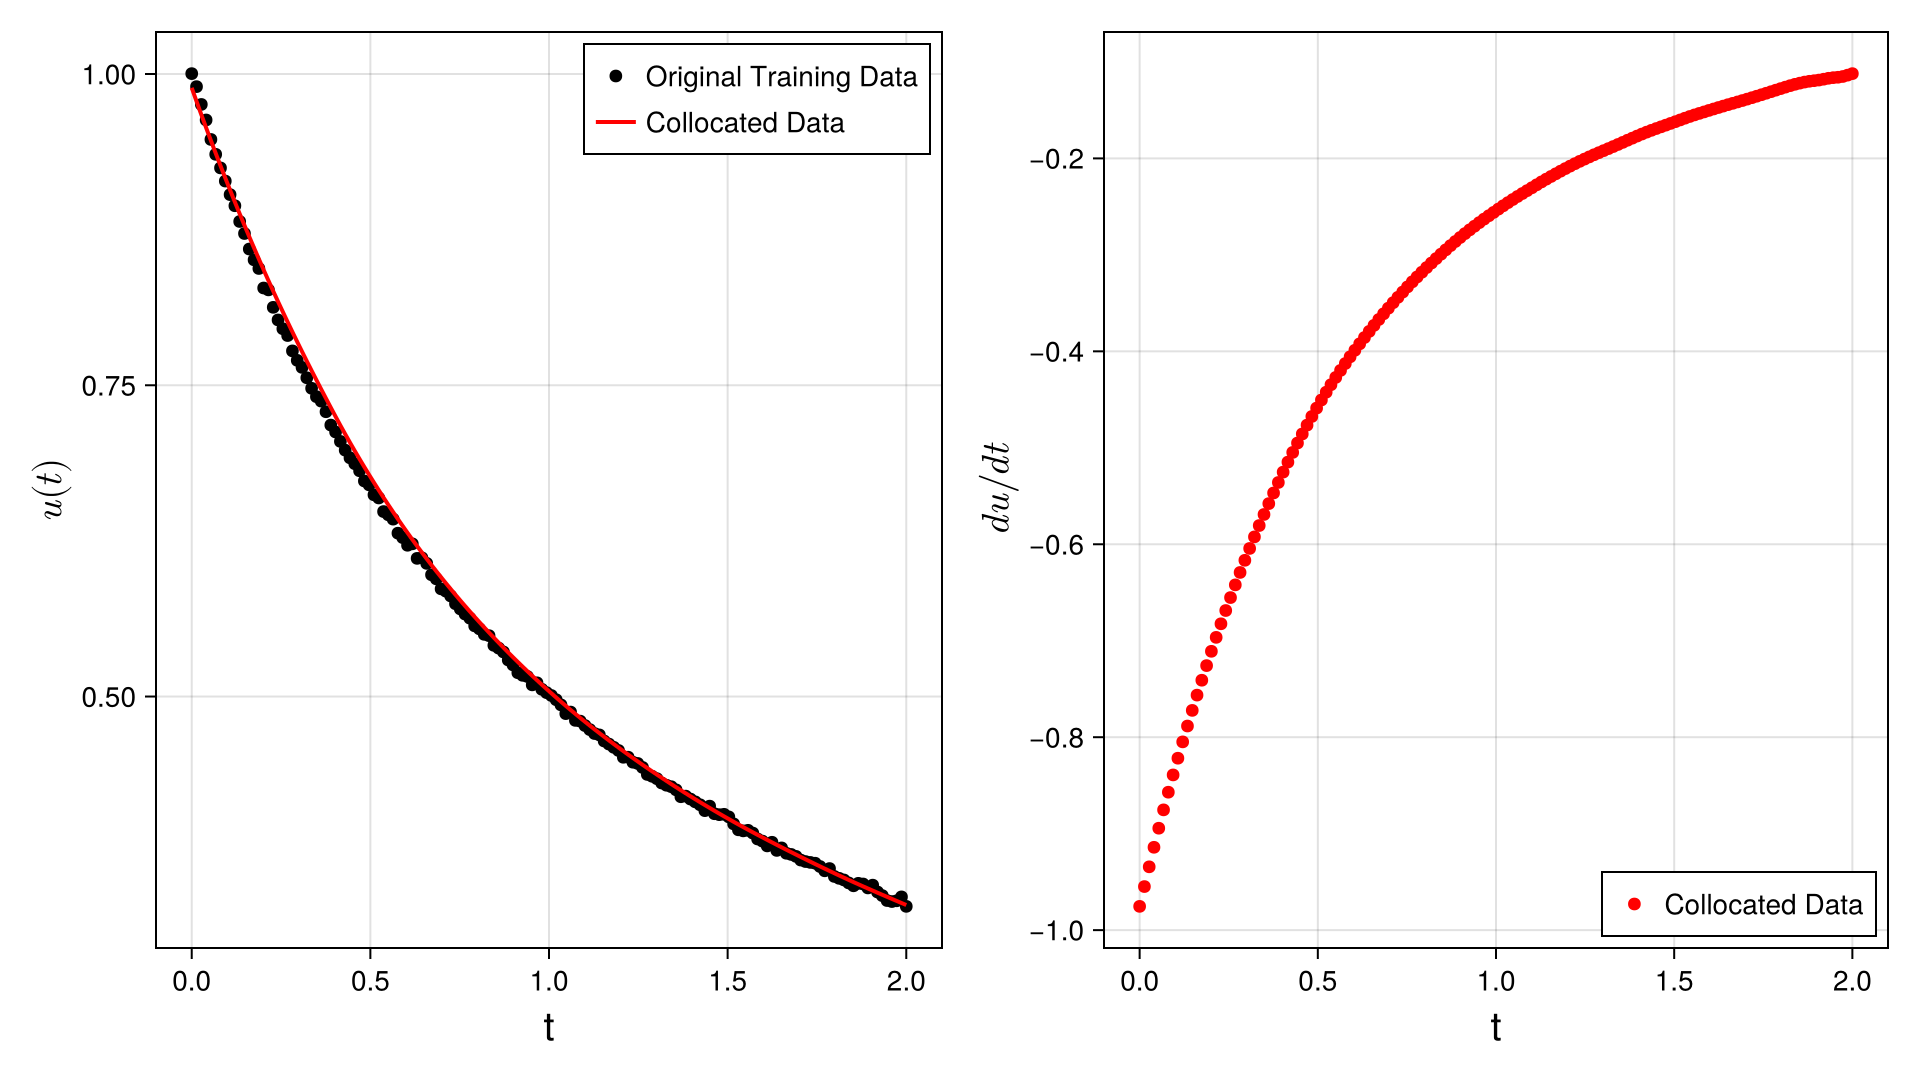

In [8]:
fig = CairoMakie.Figure(size = (960, 540), backgroundcolor = :transparent)
ax1 = CairoMakie.Axis(fig[1, 1],
    xlabelsize=20,
    ylabelsize=20,
    xlabel="t",ylabel=L"u(t)")
CairoMakie.scatter!(ax1,tsteps, data[1,:];color=:black,label="Original Training Data")
CairoMakie.lines!(ax1,tsteps, u[1,:]; linewidth=2, color=:red,label="Collocated Data")
axislegend(ax1;position=:rt)

ax2 = CairoMakie.Axis(fig[1, 2],
    xlabelsize=20,
    ylabelsize=20,
    xlabel="t",ylabel=L"du/dt")
CairoMakie.scatter!(ax2,tsteps, du[1,:];color=:red,label="Collocated Data")
axislegend(ax2;position=:rb)
fig

Define Neural Network model,$NN(u;\vec{p})$.  One input layer and one output layer with one node.  Two hidden layers with 3 nodes and using the tanh activation function for the input and hidden layers.

In [9]:
dudtNODEs = Chain(Dense(1, 3, tanh),
            Dense(3, 3, tanh),
             Dense(3, 1))
pinit, st = Lux.setup(rng, dudtNODEs)

((layer_1 = (weight = Float32[-0.08216114; -0.54444456; -2.7860525;;], bias = Float32[-0.5999714, 0.72428167, -0.4585489]), layer_2 = (weight = Float32[-0.6418321 -1.2789088 -0.2807452; 0.5387089 1.2171224 0.67334807; -0.54372525 -1.3020481 0.47613382], bias = Float32[-0.14210694, -0.5443836, -0.20890224]), layer_3 = (weight = Float32[0.9969245 0.7939795 0.45440757], bias = Float32[-0.3961207])), (layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = NamedTuple()))

Define the loss function.

$\mathcal{L}(\vec{p})=\frac{1}{2}\frac{1}{N}\sum\limits_{i=1}^{N}(NN(u_i;\vec{p})-du/dt(t_i))^2$

In [10]:
function loss(p,(du, u))
    cost = zero(first(p))
    for i in 1:size(du, 2)
        _du, _ = dudtNODEs(@view(u[:, i]), p, st)
        dui = @view du[:, i]
        cost += sum(abs2, _du .-  dui)
    end
    return 0.5*cost/size(du, 2)
end

loss (generic function with 1 method)

Collocation training.  Remember that for collocation training, we are training using the time derivative of the smoothed data.  For easy problems like this, it could lead to results that are unusually good for collocation training.  

In [11]:
# Initialize a vector to store loss values
loss_history = Float64[]

callback = function (p, l)
    if p.iter % 1000 == 0
        println("Iteration: $(p.iter), Loss: $l")
    end
    push!(loss_history, l)
    return false
end

adtype = Optimization.AutoZygote()
optf = Optimization.OptimizationFunction((p, x) -> loss(p,(du,u)), adtype)
optprob = Optimization.OptimizationProblem(optf, ComponentArray(pinit),(du,u))
result_neuralode = Optimization.solve(optprob, OptimizationOptimisers.Adam(learning_rate); callback, epochs =max_iter_colloc)

┌ Warning: Mixed-Precision `matmul_cpu_fallback!` detected and Octavian.jl cannot be used for this set of inputs (C [Matrix{Float64}]: A [Base.ReshapedArray{Float32, 2, SubArray{Float32, 1, Vector{Float32}, Tuple{UnitRange{Int64}}, true}, Tuple{}}] x B [Base.ReshapedArray{Float64, 2, SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}, Tuple{}}]). Converting to common type to to attempt to use BLAS. This may be slow.
└ @ LuxLib.Impl /Users/asho/.julia/packages/LuxLib/zPBrt/src/impl/matmul.jl:198


Iteration: 1000, Loss: 2.436914674687491e-5
Iteration: 2000, Loss: 1.0967118523727801e-5
Iteration: 3000, Loss: 5.372347862988273e-6
Iteration: 4000, Loss: 2.5814614795517936e-6
Iteration: 5000, Loss: 1.188782929929912e-6
Iteration: 5000, Loss: 1.188782929929912e-6


retcode: Default
u: ComponentVector{Float32}(layer_1 = (weight = Float32[0.031657588; -0.55499715; -1.6156346;;], bias = Float32[-0.7040333, 0.65316063, 1.9534855]), layer_2 = (weight = Float32[-0.77605116 -0.9991325 -0.41815105; 0.4568912 1.6907473 0.58571637; -0.2877543 -0.97576535 0.60245645], bias = Float32[0.002005959, -0.4453416, -0.4259974]), layer_3 = (weight = Float32[0.034872986 1.0650383 0.3113437], bias = Float32[-0.58051455]))

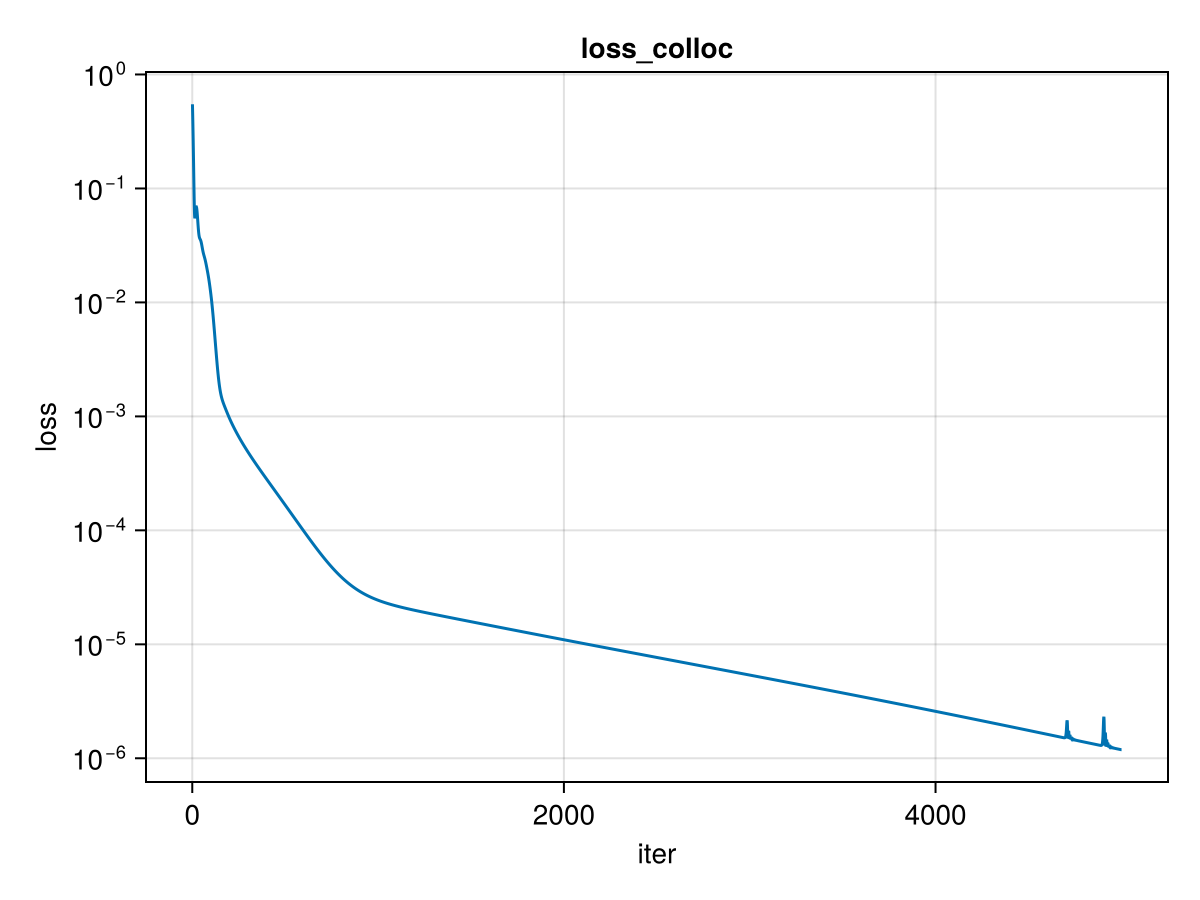

In [12]:
#Plot history of the loss function
#
loss_history_collocation=copy(loss_history)
fig = CairoMakie.Figure()
ax = CairoMakie.Axis(fig[1, 1],yscale=log10,xlabel="iter",ylabel="loss",title="loss_colloc")
CairoMakie.lines!(ax,loss_history_collocation)
fig

Predict using model for collocation training and compare with validation data

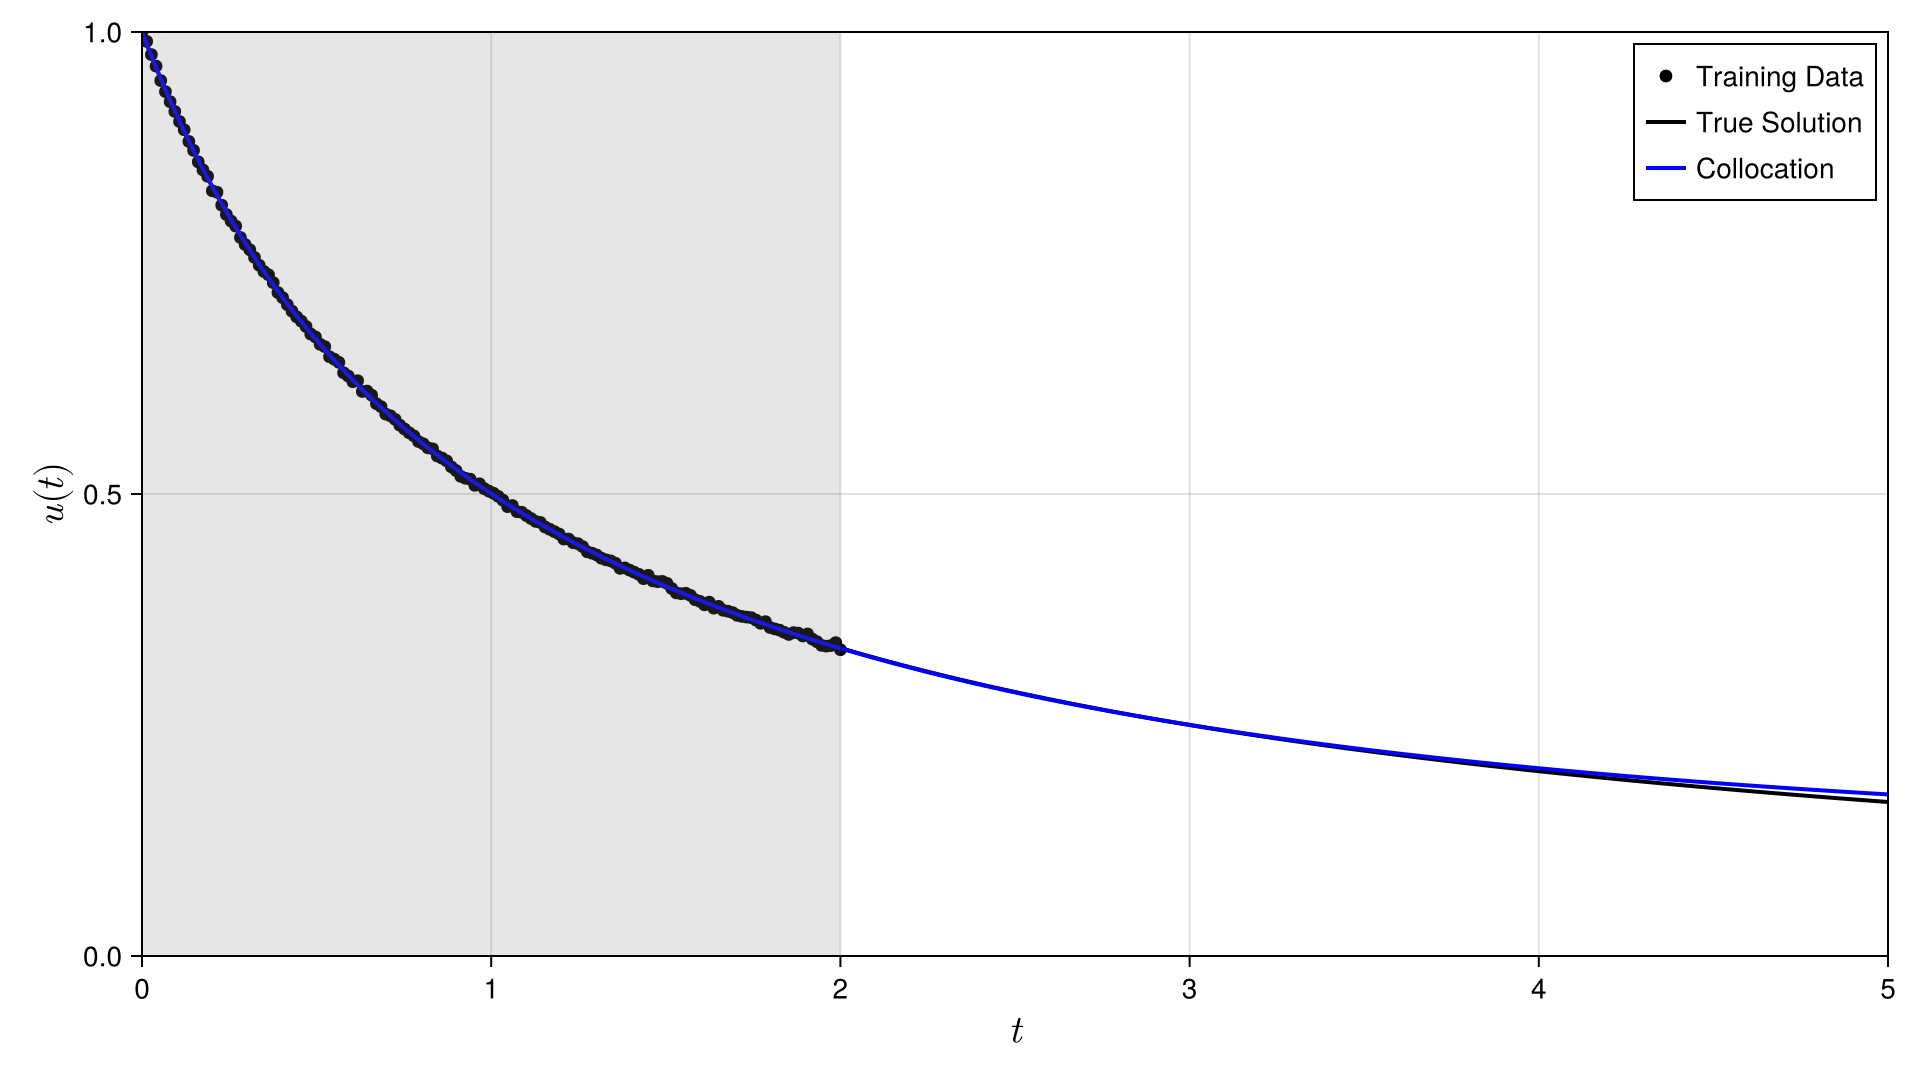

In [13]:
smodel_colloc = StatefulLuxLayer(dudtNODEs, result_neuralode, st)
dudt_colloc(u, p, t) = smodel_colloc(u, p)
prob_colloc = ODEProblem(dudt_colloc, u0, (tspan2[1], tspan2[2]),result_neuralode.u)
nn_sol_colloc = solve(prob_colloc, Tsit5(); saveat=tsteps2)
ComputedSolutionColloc=convert(AbstractArray,nn_sol_colloc)

fig5 = CairoMakie.Figure(size = (960, 540), backgroundcolor = :transparent)
ax5 = CairoMakie.Axis(fig5[1, 1],
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u(t)")
CairoMakie.scatter!(ax5,tsteps, data[1,:];color=:black,label="Training Data")
CairoMakie.lines!(ax5,tsteps2, data_true[1,:]; linewidth = 2,color=:black,label="True Solution")
CairoMakie.lines!(ax5,nn_sol_colloc.t,ComputedSolutionColloc[1,:]; linewidth = 2,color=:blue,linestyle=:solid,label="Collocation")
CairoMakie.vspan!(ax5,tspan[1], tspan[2];color=(:grey, 0.2))
xlims!(ax5,tspan2[1],tspan2[2])
ylims!(ax5,0,1)
axislegend(ax5;position=:rt)
fig5

Now do NODEs training using the adjoint method. Remember that for NODEs training, we are training using the original noisy data.  This might explain the slight differences between NODEs and collocation training.   The more noise we add, there is increased likelihood of the differences between the results of the two training methodologies.  

In [14]:
smodel = StatefulLuxLayer(dudtNODEs, result_neuralode, st)

function loss_adjoint(p, (u, t))
    u0 = u[:, 1]
    dudt(u, θ, t) = smodel(u, θ)
    prob = ODEProblem(dudt, u0, (t[1], t[end]), p)
    sol = solve(prob, Tsit5();  saveat=t, sensealg=ReverseDiffAdjoint())
    pred = stack(sol.u)

    return MSELoss()(pred, u)
end

loss_history = Float64[]
opt_func = OptimizationFunction(loss_adjoint, Optimization.AutoZygote())
opt_prob = OptimizationProblem(opt_func, result_neuralode.u, (data,tsteps))
numerical_neuralode = Optimization.solve(opt_prob, Optimisers.Adam(learning_rate); callback, epochs = max_iter_NODEs)
loss_history_NODEs=copy(loss_history)


Iteration: 1000, Loss: 3.3711900005564597e-6
Iteration: 2000, Loss: 3.371592598104967e-6
Iteration: 3000, Loss: 3.3751116890711872e-6
Iteration: 4000, Loss: 3.4002263829617287e-6
Iteration: 5000, Loss: 3.395116063648265e-6
Iteration: 6000, Loss: 3.4028780510547066e-6
Iteration: 7000, Loss: 4.079587386417323e-6
Iteration: 8000, Loss: 3.4194597160379268e-6
Iteration: 9000, Loss: 3.4257902751615193e-6
Iteration: 10000, Loss: 3.432151326139485e-6
Iteration: 10000, Loss: 3.3659840474090207e-6


10001-element Vector{Float64}:
 3.3956976194613597e-6
 0.0017628504034064908
 5.3688702153253365e-5
 0.0006082628710955754
 0.0011162491403694296
 0.0006538803117666481
 0.00010407339329538247
 6.29538751701205e-5
 0.0003967381053219989
 0.0005689052596261479
 ⋮
 3.4326874937671895e-6
 3.4326119306657525e-6
 3.4325357283461855e-6
 3.432458489603828e-6
 3.432381885253137e-6
 3.4323070997274283e-6
 3.4322291764737e-6
 3.432151326139485e-6
 3.3659840474090207e-6

Predict using NODEs solution and plot

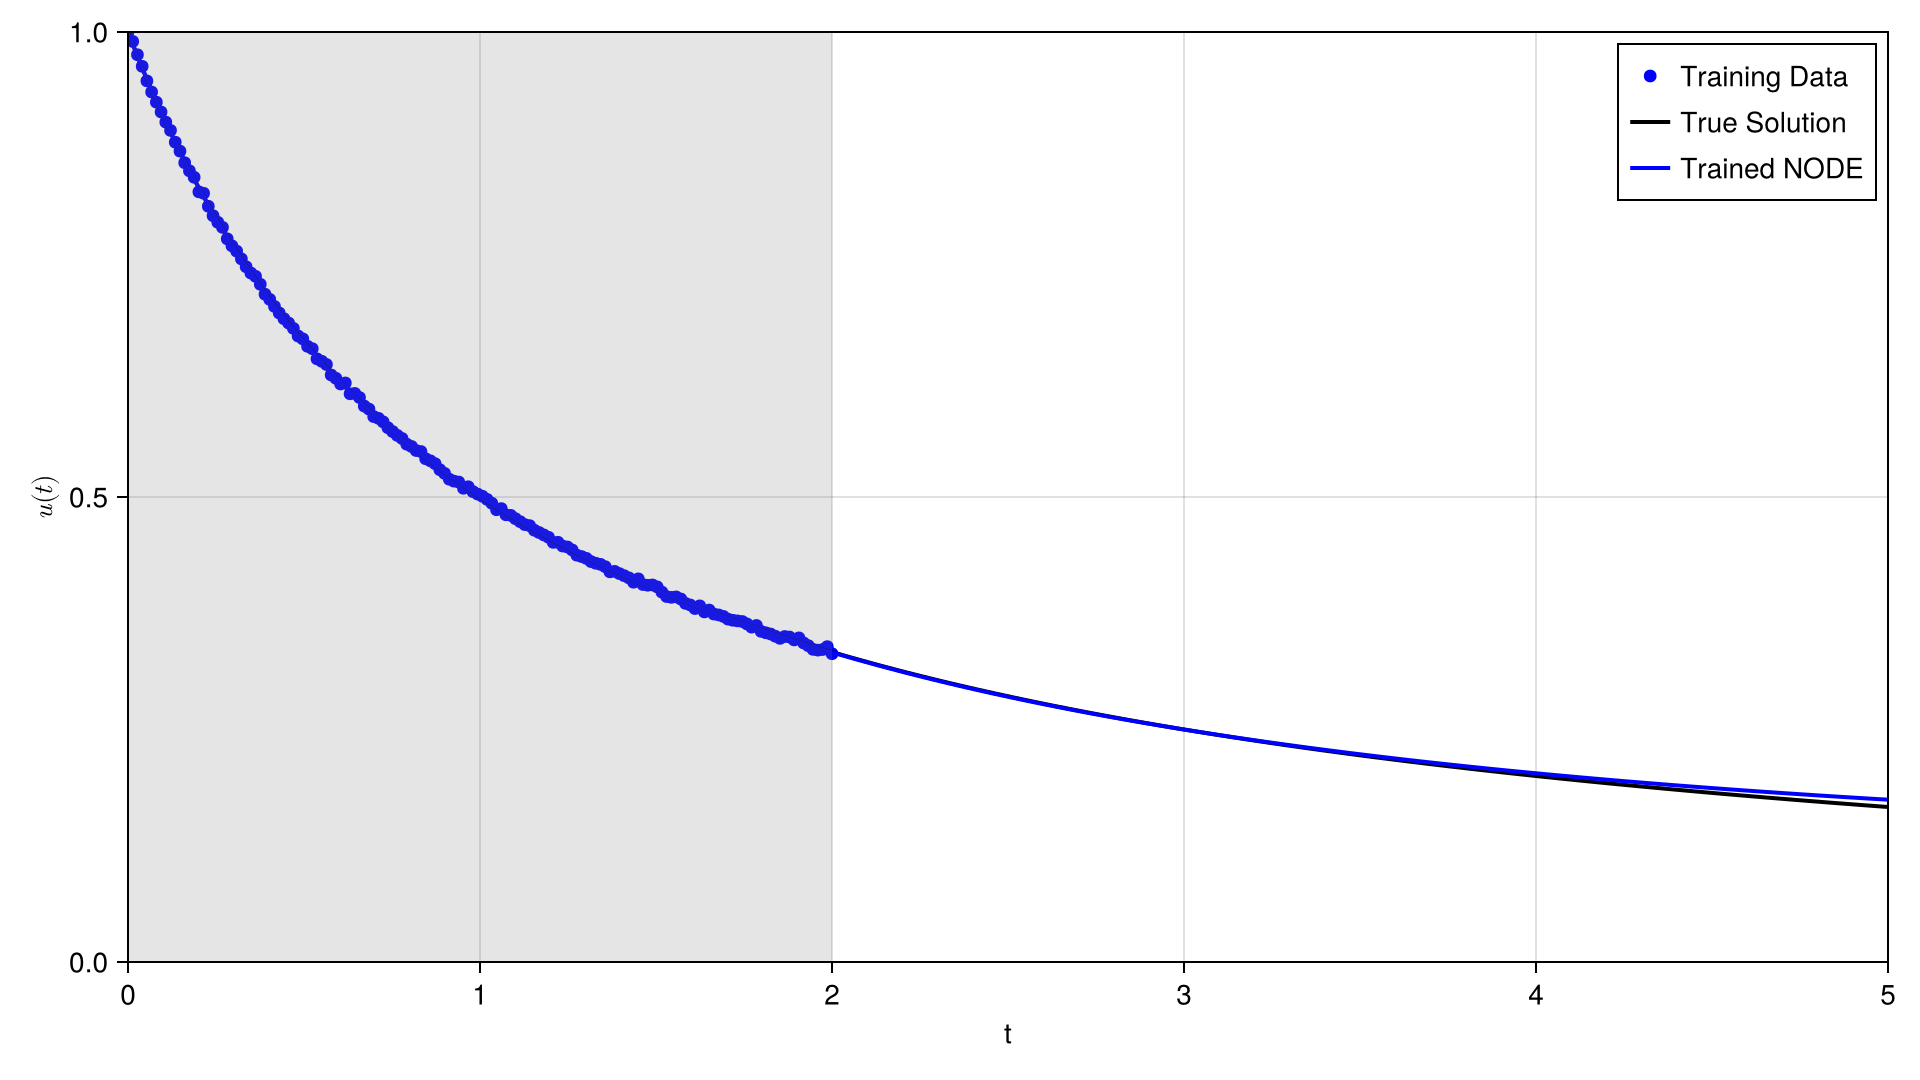

In [15]:
trained_model=StatefulLuxLayer(dudtNODEs, numerical_neuralode, smodel.st)
Finaldudt(u, p, tplot) = trained_model(u, p)
prob = ODEProblem(Finaldudt, u0, (tspan2[1],tspan2[2]), numerical_neuralode.u) 
nn_sol = solve(prob, Tsit5(); saveat=tsteps2)


ComputedSolution_nodes=convert(AbstractArray,nn_sol)

fig = CairoMakie.Figure(size = (960, 540), backgroundcolor = :transparent)
ax = CairoMakie.Axis(fig[1, 1],xlabel="t",ylabel=L"u(t)")
CairoMakie.scatter!(ax,tsteps, data[1,:];color=:blue,label="Training Data")
CairoMakie.lines!(ax,tsteps2, data_true[1,:]; linewidth = 2,color=:black,label="True Solution")
CairoMakie.lines!(ax,nn_sol.t,ComputedSolution_nodes[1,:]; linewidth = 2,color=:blue,linestyle=:solid,label="Trained NODE")
CairoMakie.vspan!(ax,tspan[1], tspan[2];color=(:grey, 0.2))
xlims!(ax,tspan2[1],tspan2[2])
ylims!(ax,0,1)
axislegend(ax;position=:rt)
fig

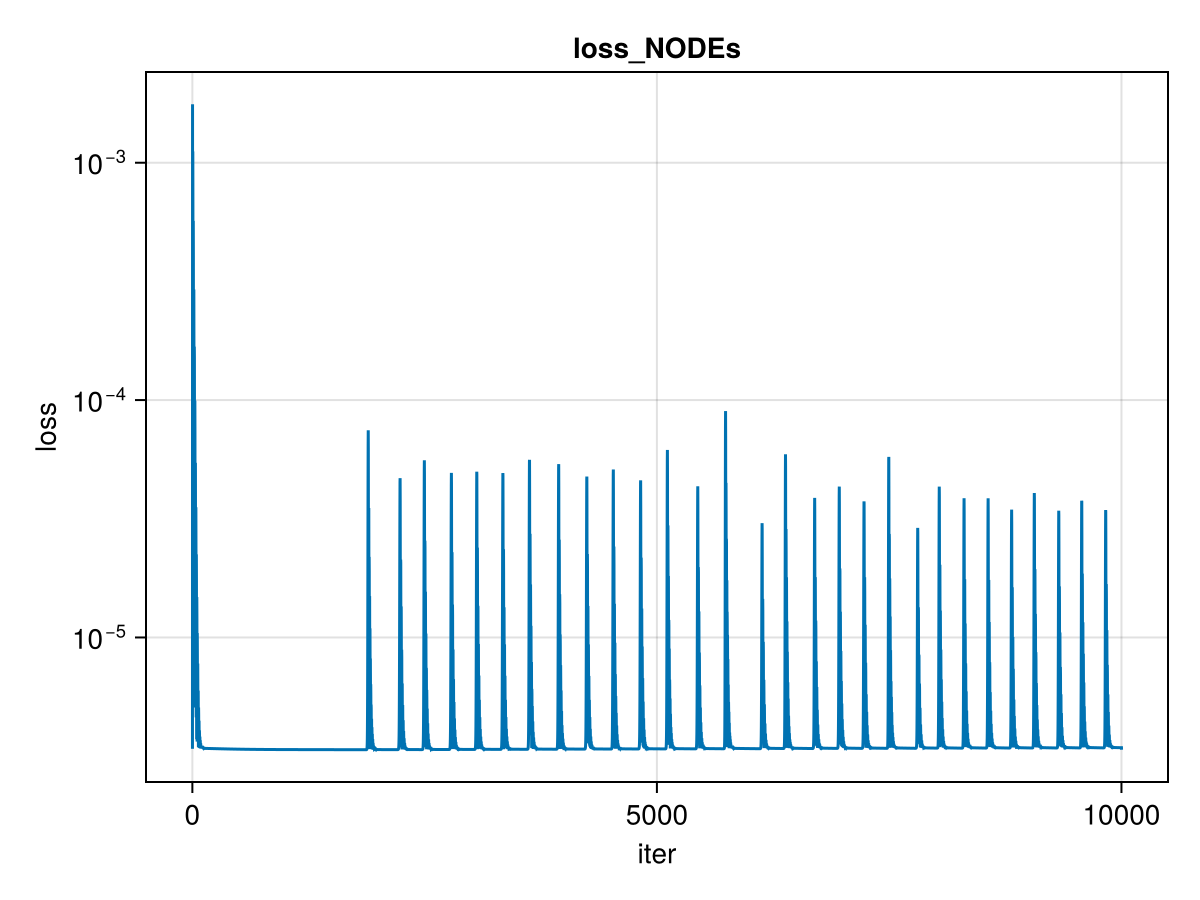

In [16]:
fig = CairoMakie.Figure()
ax = CairoMakie.Axis(fig[1, 1],yscale=log10,xlabel="iter",ylabel="loss",title="loss_NODEs")
CairoMakie.lines!(ax,loss_history_NODEs)
save("loss_NODEs.png", fig)
fig
